In [ ]:
# from data_tools.db import Manager

# engine = Manager("mvh-admin", "mvh").engine

# from mff.new_cap import generate_extended_base_data
# generate_extended_base_data(2024, engine)

In [1]:
from mff.new_cap import (
    read_extended_base_data,
    compute_capped_subsidies,
    analyze_by_area_categories,
    find_budget,
    calc_degressive_and_capping_steps,
    generate_labels_from_bins,
)

from mff.plots import PolicyParams, plot_per_ha

from mff.utils import c_round

from collections.abc import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.axes import Axes
from matplotlib.container import BarContainer
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, MultipleLocator

import statsmodels.api as sm

In [2]:
def add_bar_labels(
    ax: Axes,
    bars: BarContainer | Iterable[Rectangle],
    fmt: str = "{:,}",
    percent: bool = False,
) -> None:
    max_val = float("-inf")
    min_val = float("inf")

    for bar in bars:
        h = bar.get_height()
        label = f"{h:.1f} %" if percent else fmt.format(int(h)).replace(",", " ")

        # lefelé kerül a negatív felirat
        offset = 5 if h >= 0 else -5

        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if h >= 0 else "top",
            fontsize=9,
        )
        max_val = max(max_val, h)
        min_val = min(min_val, h)

    data_range = max_val - min_val if max_val != min_val else abs(max_val)
    margin = data_range * 0.155 if data_range > 0 else abs(max_val) * 0.155

    if min_val >= 0:
        ax.set_ylim(0, max_val + margin)
    else:
        ax.set_ylim(min(0, min_val - margin), max_val + margin)

In [3]:
def plot_support_summary_by_area_class(
    data: pd.DataFrame,
    coupled_payments: dict[str, dict[str, float]],
    dabis_per_ha: float,
    redist_per_ha: tuple[float, float],
    bins: list[float],
    labels: list[str],
    allocation: float,
    cis_ratio: float = 1,
    flat_rate: float = 0,
) -> None:
    data_with_subs = compute_capped_subsidies(data, dabis_per_ha, 90, redist_per_ha)

    cis_columns = [
        "subs_tk_cukorrepa",
        "subs_tk_szemes_feherjenoveny",
        "subs_tk_szalas_feherjenoveny",
        "subs_tk_extenziv_gyumolcs",
        "subs_tk_intenziv_gyumolcs",
        "subs_tk_ipari_olajnoveny",
        "subs_tk_ipari_zoldsegnoveny",
        "subs_tk_zoldsegnoveny",
        "subs_tk_rizs",
        "subs_tk_hizottbika",
        "subs_tk_anyatehen",
        "subs_tk_tejhasznu_tehen",
        "subs_tk_anyajuh",
    ]

    cis_new_columns = [
        "subs_new_tk_cukorrepa",
        "subs_new_tk_szemes_feherjenoveny",
        "subs_new_tk_szalas_feherjenoveny",
        "subs_new_tk_extenziv_gyumolcs",
        "subs_new_tk_intenziv_gyumolcs",
        "subs_new_tk_ipari_olajnoveny",
        "subs_new_tk_ipari_zoldsegnoveny",
        "subs_new_tk_zoldsegnoveny",
        "subs_new_tk_rizs",
        "subs_new_tk_hizottbika",
        "subs_new_tk_anyatehen",
        "subs_new_tk_tejhasznu_tehen",
        "subs_new_tk_anyajuh",
    ]

    data_with_subs["subs_cur"] = (
        data_with_subs["subs_biss"]
        + data_with_subs["subs_redist"]
        + data_with_subs["subs_yfs"]
        + data_with_subs[cis_columns].fillna(0).sum(axis=1)
        + data_with_subs["subs_aop"].fillna(0)
        + data_with_subs["subs_vp_akg_2021"].fillna(0)
    )

    tk_feh = sum(
        coupled_payments[key]["budget"]
        for key in coupled_payments
        if key in ["tk_szalas_feherjenoveny", "tk_szemes_feherjenoveny"]
    )

    tk_nem_feh = sum(
        coupled_payments[key]["budget"]
        for key in coupled_payments
        if key not in ["tk_szalas_feherjenoveny", "tk_szemes_feherjenoveny"]
    )

    CIS_prot_ratio = (5 / 25 * 202_110_350) / tk_feh
    CIS_non_prot_ratio = (20 / 25 * 202_110_350) / tk_nem_feh

    for key in coupled_payments.keys():
        if key in ["tk_szalas_feherjenoveny", "tk_szemes_feherjenoveny"]:
            data_with_subs[f"subs_new_{key}"] = (
                CIS_prot_ratio * data_with_subs[f"subs_{key}"]
            )
        else:
            data_with_subs[f"subs_new_{key}"] = (
                CIS_non_prot_ratio * data_with_subs[f"subs_{key}"]
            )

    data_with_subs["subs_capped"] += (
        cis_ratio * data_with_subs[cis_new_columns].fillna(0).sum(axis=1)
        + flat_rate * data_with_subs["area_aop"]
    )

    grouped_result = analyze_by_area_categories(
        data_with_subs, bins=bins, labels=labels
    )

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(10, 12), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]}
    )

    bars1 = ax1.bar(
        grouped_result.index,
        grouped_result["total_farmers"],
        color="#0072B2",
        alpha=0.85,
    )
    ax1.set_ylabel("Gazdálkodók száma (db)", fontsize=12)
    ax1.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
    )
    add_bar_labels(ax1, bars1)

    bars2 = ax2.bar(
        grouped_result.index, grouped_result["total_area"], color="#56B4E9", alpha=0.85
    )
    ax2.set_ylabel("Összes terület (ha)", fontsize=12)
    ax2.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))
    )
    add_bar_labels(ax2, bars2)

    bars3 = ax3.bar(
        grouped_result.index,
        grouped_result["avg_change"],
        color=[
            "#009E73" if v >= 0 else "#B22222" for v in grouped_result["avg_change"]
        ],
        alpha=0.85,
    )
    ax3.set_ylabel("Fajlagos támogatás változása (%)", fontsize=12)
    ax3.axhline(0, color="gray", linestyle="--", linewidth=1)
    add_bar_labels(ax3, bars3, percent=True)

    ax3.set_xlabel("Méretkategória (ha)", fontsize=12)

    # fig.suptitle(
    #     f"Támogatások alakulása gazdálkodói méretkategóriák szerint\n{allocation / 1e6:.1f} millió EUR borítékkal DABIS borítékkal számolva".replace(
    #         ".", ","
    #     ),
    #     fontsize=14,
    #     fontweight="bold",
    #     x=0.5,
    #     y=0.95,
    # )

    fig.align_ylabels([ax1, ax2, ax3])
    plt.subplots_adjust(left=0.12, hspace=0.2)
    plt.savefig(f"output/abra_osszetett_{allocation / 1e6:.1f}.png", dpi=300)
    plt.show()
    return data_with_subs

In [4]:
data = read_extended_base_data(2024)

BISS = 735_300_015.55
CRISS = 189_176_282.80
YFS = 18_690_804.00
BISS_CRISS_YFS = 943_167_102.35
CIS_CUR = 202_110_350
ECO_SCHEMES = 202_125_000
AKG_2021 = 376_417_351.59  # (412.177 * 1e9 / 365) / 3 # https://www.nak.hu/tajekoztatasi-szolgaltatas/kornyezetgazdalkodas/104645-vpakg2021-szamokban

coupled_payments = {
    "tk_cukorrepa": {"budget": 7_915_693.20, "min": 424.52, "max": 881.70},
    "tk_szemes_feherjenoveny": {"budget": 15_962_772.76, "min": 163.01, "max": 302.73},
    "tk_szalas_feherjenoveny": {"budget": 10_985_262.30, "min": 44.92, "max": 77.00},
    "tk_extenziv_gyumolcs": {"budget": 6_063_331.33, "min": 143.54, "max": 191.39},
    "tk_intenziv_gyumolcs": {"budget": 6_653_919.68, "min": 280.11, "max": 429.50},
    "tk_ipari_olajnoveny": {"budget": 740_499.63, "min": 76.71, "max": 142.47},
    "tk_ipari_zoldsegnoveny": {"budget": 15_619_889.00, "min": 260.44, "max": 390.66},
    "tk_zoldsegnoveny": {"budget": 6_455_314.80, "min": 180.92, "max": 289.48},
    "tk_rizs": {"budget": 1_979_171.48, "min": 582.75, "max": 874.13},
    "tk_hizottbika": {"budget": 5_061_180.70, "min": 40.76, "max": 65.22},
    "tk_anyatehen": {"budget": 34_631_327.25, "min": 111.96, "max": 174.94},
    "tk_tejhasznu_tehen": {"budget": 68_274_257.17, "min": 237.74, "max": 396.24},
    "tk_anyajuh": {"budget": 21_767_730.60, "min": 24.16, "max": 35.53},
}

CIS_CUR - sum(item["budget"] for item in coupled_payments.values())

aop_fajlagos = 47.92  # ECO_SCHEMES / data["area_aop"].sum()
vp_akg_2021_fajlagos = 313.57  # AKG_2021 / data["area_vp_akg_2021"].sum()

tk_cukorrepa_fajlagos = 490.56  # coupled_payments["tk_cukorrepa"]["budget"] / data["area_tk_cukorrepa"].sum()
tk_szemes_feherjenoveny_fajlagos = 130.02  # coupled_payments["tk_szemes_feherjenoveny"]["budget"] / data["area_tk_szemes_feherjenoveny"].sum()
tk_szalas_feherjenoveny_fajlagos = 66.34  # coupled_payments["tk_szalas_feherjenoveny"]["budget"] / data["area_tk_szalas_feherjenoveny"].sum()
tk_extenziv_gyumolcs_fajlagos = 199.75  # coupled_payments["tk_extenziv_gyumolcs"]["budget"] / data["area_tk_extenziv_gyumolcs"].sum()
tk_intentziv_gyumolcs_fajlagos = 378.81  # coupled_payments["tk_intenziv_gyumolcs"]["budget"] / data["area_tk_intenziv_gyumolcs"].sum()
tk_ipari_olajnoveny_fajlagos = 121.58  # coupled_payments["tk_ipari_olajnoveny"]["budget"] / data["area_tk_ipari_olajnoveny"].sum()
tk_ipari_zoldsegnoveny_fajlagos = 384.99  # coupled_payments["tk_ipari_zoldsegnoveny"]["budget"] / data["area_tk_ipari_zoldsegnoveny"].sum()
tk_zoldsegnoveny_fajlagos = 135.63  # coupled_payments["tk_zoldsegnoveny"]["budget"] / data["area_tk_zoldsegnoveny"].sum()
tk_rizs_fajlagos = (
    840.68  # coupled_payments["tk_rizs"]["budget"] / data["area_tk_rizs"].sum()
)
tk_hizottbika_fajlagos = 95.96  # coupled_payments["tk_hizottbika"]["budget"] / data["count_tk_hizottbika"].sum()
tk_anyatehen_fajlagos = 168.12  # coupled_payments["tk_anyatehen"]["budget"] / data["count_tk_anyatehen"].sum()
tk_tejhasznu_tehen_fajlagos = 168.12  # coupled_payments["tk_tejhasznu_tehen"]["budget"] / data["count_tk_tejhasznu_tehen"].sum()
tk_anyajuh_fajlagos = (
    35.25  # coupled_payments["tk_anyajuh"]["budget"] / data["count_tk_anyajuh"].sum()
)

data["subs_aop"] = aop_fajlagos * data["area_aop"]
data["subs_vp_akg_2021"] = vp_akg_2021_fajlagos * data["area_vp_akg_2021"]
data["subs_tk_cukorrepa"] = tk_cukorrepa_fajlagos * data["area_tk_cukorrepa"]
data["subs_tk_szemes_feherjenoveny"] = (
    tk_szemes_feherjenoveny_fajlagos * data["area_tk_szemes_feherjenoveny"]
)
data["subs_tk_szalas_feherjenoveny"] = (
    tk_szalas_feherjenoveny_fajlagos * data["area_tk_szalas_feherjenoveny"]
)
data["subs_tk_extenziv_gyumolcs"] = (
    tk_extenziv_gyumolcs_fajlagos * data["area_tk_extenziv_gyumolcs"]
)
data["subs_tk_intenziv_gyumolcs"] = (
    tk_intentziv_gyumolcs_fajlagos * data["area_tk_intenziv_gyumolcs"]
)
data["subs_tk_ipari_olajnoveny"] = (
    tk_ipari_olajnoveny_fajlagos * data["area_tk_ipari_olajnoveny"]
)
data["subs_tk_ipari_zoldsegnoveny"] = (
    tk_ipari_zoldsegnoveny_fajlagos * data["area_tk_ipari_zoldsegnoveny"]
)
data["subs_tk_zoldsegnoveny"] = (
    tk_zoldsegnoveny_fajlagos * data["area_tk_zoldsegnoveny"]
)
data["subs_tk_rizs"] = tk_rizs_fajlagos * data["area_tk_rizs"]
data["subs_tk_hizottbika"] = tk_hizottbika_fajlagos * data["count_tk_hizottbika"]
data["subs_tk_anyatehen"] = tk_anyatehen_fajlagos * data["count_tk_anyatehen"]
data["subs_tk_tejhasznu_tehen"] = (
    tk_tejhasznu_tehen_fajlagos * data["count_tk_tejhasznu_tehen"]
)
data["subs_tk_anyajuh"] = tk_anyajuh_fajlagos * data["count_tk_anyajuh"]

data["subs_total"] = (
    data["subs_biss"].fillna(0)
    + data["subs_redist"].fillna(0)
    + data["subs_yfs"].fillna(0)
    + data["subs_aop"].fillna(0)
    + data["subs_vp_akg_2021"].fillna(0)
    + data["subs_tk_cukorrepa"].fillna(0)
    + data["subs_tk_szemes_feherjenoveny"].fillna(0)
    + data["subs_tk_extenziv_gyumolcs"].fillna(0)
    + data["subs_tk_intenziv_gyumolcs"].fillna(0)
    + data["subs_tk_ipari_olajnoveny"].fillna(0)
    + data["subs_tk_ipari_zoldsegnoveny"].fillna(0)
    + data["subs_tk_zoldsegnoveny"].fillna(0)
    + data["subs_tk_rizs"].fillna(0)
    + data["subs_tk_hizottbika"].fillna(0)
    + data["subs_tk_anyatehen"].fillna(0)
    + data["subs_tk_tejhasznu_tehen"].fillna(0)
    + data["subs_tk_anyajuh"].fillna(0)
)

data["ratio"] = (data["subs_biss"] + data["subs_redist"] + data["subs_yfs"]) / data[
    "subs_total"
]
data["ratio"] = data["ratio"].fillna(0)
data["aop_status"] = np.where(data["area_aop"] > 0, 1, 0)

other_subs_cols = [
    "subs_vp_akg_2021",
    "subs_tk_cukorrepa",
    "subs_tk_szemes_feherjenoveny",
    "subs_tk_szalas_feherjenoveny",
    "subs_tk_extenziv_gyumolcs",
    "subs_tk_intenziv_gyumolcs",
    "subs_tk_ipari_olajnoveny",
    "subs_tk_ipari_zoldsegnoveny",
    "subs_tk_zoldsegnoveny",
    "subs_tk_rizs",
    "subs_tk_hizottbika",
    "subs_tk_anyatehen",
    "subs_tk_tejhasznu_tehen",
    "subs_tk_anyajuh",
]

basic_subs_cols = ["subs_biss", "subs_redist", "subs_yfs", "subs_aop"]

mask1 = data[other_subs_cols].fillna(0).sum(axis=1) == 0
mask2 = data[basic_subs_cols].fillna(0).sum(axis=1) > 0

data["only_biss_criss_yfs"] = np.where(mask1 & mask2, 1, 0)

other_subs_cols = [
    "subs_vp_akg_2021",
]

basic_subs_cols = [
    "subs_biss",
    "subs_redist",
    "subs_yfs",
    "subs_aop",
    "subs_tk_cukorrepa",
    "subs_tk_szemes_feherjenoveny",
    "subs_tk_szalas_feherjenoveny",
    "subs_tk_extenziv_gyumolcs",
    "subs_tk_intenziv_gyumolcs",
    "subs_tk_ipari_olajnoveny",
    "subs_tk_ipari_zoldsegnoveny",
    "subs_tk_zoldsegnoveny",
    "subs_tk_rizs",
    "subs_tk_hizottbika",
    "subs_tk_anyatehen",
    "subs_tk_tejhasznu_tehen",
    "subs_tk_anyajuh",
]

mask1 = data[other_subs_cols].fillna(0).sum(axis=1) == 0
mask2 = data[basic_subs_cols].fillna(0).sum(axis=1) > 0

data["doesnt_apply_for_akg"] = np.where(mask1 & mask2, 1, 0)

In [5]:
tk_feh = sum(
    coupled_payments[key]["budget"]
    for key in coupled_payments
    if key in ["tk_szalas_feherjenoveny", "tk_szemes_feherjenoveny"]
)

tk_nem_feh = sum(
    coupled_payments[key]["budget"]
    for key in coupled_payments
    if key not in ["tk_szalas_feherjenoveny", "tk_szemes_feherjenoveny"]
)

CIS_prot_ratio = (5 / 25 * 202_110_350) / tk_feh
CIS_non_prot_ratio = (20 / 25 * 202_110_350) / tk_nem_feh

In [6]:
arr = np.linspace(4_955_337.8865 * 130, 4_955_337.8865 * 240, 100)
rf = 1_319_899_142.85 - arr

In [7]:
def calc_nrf():
    arr_dabis = np.linspace(4_955_337.8865 * 130, 4_955_337.8865 * 240, 10000)
    arr_cis = 1_319_899_142.85 - arr_dabis
    arr_nrf = 4 * 1_319_899_142.85 - 5 * arr_dabis
    return arr_dabis / 1e6, arr_cis / 1e6, arr_nrf / 1e6

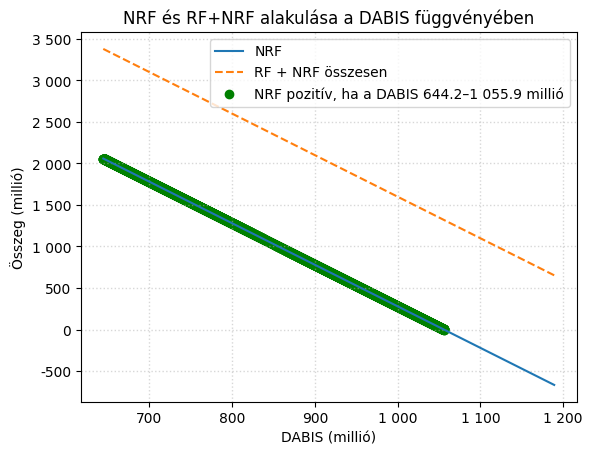

In [8]:
arr_dabis, arr_cis, arr_nrf = calc_nrf()

arr_total = arr_cis + arr_dabis + arr_nrf

mask = arr_nrf > 0
dabis_min = arr_dabis[mask].min()
dabis_max = arr_dabis[mask].max()


def fmt(x):
    return f"{x:,.1f}".replace(",", " ")


def space_thousands(x, pos):
    return f"{x:,.0f}".replace(",", " ")


plt.figure()

plt.plot(arr_dabis, arr_nrf, label="NRF")
plt.plot(arr_dabis, arr_total, linestyle="--", label="RF + NRF összesen")

plt.scatter(
    arr_dabis[mask],
    arr_nrf[mask],
    color="green",
    label=f"NRF pozitív, ha a DABIS {fmt(dabis_min)}–{fmt(dabis_max)} millió",
)

plt.xlabel("DABIS (millió)")
plt.ylabel("Összeg (millió)")
plt.title("NRF és RF+NRF alakulása a DABIS függvényében")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.yaxis.set_major_locator(MultipleLocator(500))

ax.grid(which="major", axis="y", linestyle=":", linewidth=1, alpha=0.5)

ax.grid(which="major", axis="x", linestyle=":", linewidth=1, alpha=0.5)
ax.xaxis.set_major_formatter(FuncFormatter(space_thousands))
ax.yaxis.set_major_formatter(FuncFormatter(space_thousands))

plt.legend()
plt.show()

In [9]:
data["area_biss_criss"].sum()

np.float64(4955337.8865)


DABIS_PER_HA: 160.0 EUR / ha
CIS:          497.93 millió EUR
DABIS:        821.97 millió EUR
RF:          1319.9 millió EUR
NRF:          1169.75 millió EUR
Total:       2489.64 millió EUR
Ratio:       0.25 millió EUR,
Helper:      497928944.97, 821970197.88, 1169745582.0



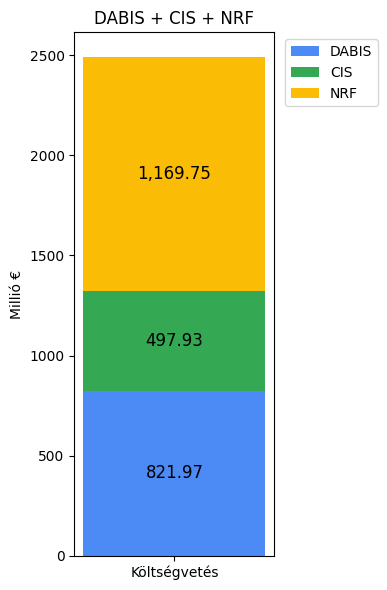

In [10]:
# DABIS_BUDGET_MINISTRY = 943_167_086.78
# REDIST_PER_HA = (80.00, 40.00)
# DABIS_PER_HA = 148.1
CIS_CUR = 202_110_350
BUDGET_CAP_RF_7_YEAR = 9_239_294_000

AREA = data["area_biss_criss"].sum()
(130 * AREA, 240 * AREA)
RF = 1_319_899_142.85
YFS_PER_HA = 90
REDIST_PER_HA = (80, 40)
# DABIS_PER_HA = 197.83 # scenario - ministry
DABIS_PER_HA = 160
# DABIS_PER_HA = 210
# DABIS_PER_HA = 185.411
#


DABIS_BUDGET = find_budget(data, DABIS_PER_HA, YFS_PER_HA, REDIST_PER_HA).root
CIS_NEW = RF - DABIS_BUDGET
NRF = 4 * RF - 5 * DABIS_BUDGET

print(
    f"""
DABIS_PER_HA: {c_round(DABIS_PER_HA, 2)} EUR / ha
CIS:          {c_round(CIS_NEW / 1e6, 2)} millió EUR
DABIS:        {c_round(DABIS_BUDGET / 1e6, 2)} millió EUR
RF:          {c_round(RF / 1e6, 2)} millió EUR
NRF:          {c_round(NRF / 1e6, 2)} millió EUR
Total:       {c_round((RF + NRF) / 1e6, 2)} millió EUR
Ratio:       {c_round(CIS_NEW / (DABIS_BUDGET + NRF), 2)} millió EUR,
Helper:      {c_round(CIS_NEW, 2)}, {c_round(DABIS_BUDGET, 2)}, {c_round(NRF, 2)}
"""
)

scale = 1e6
vals = [DABIS_BUDGET / scale, CIS_NEW / scale, NRF / scale]

labels = ["DABIS", "CIS", "NRF"]
colors = ["#4c8bf5", "#34a853", "#fbbc05"]

fig, ax = plt.subplots(figsize=(4, 6))

bottom = 0
for value, label, color in zip(vals, labels, colors):
    ax.bar("Költségvetés", value, bottom=bottom, label=label, color=color)
    ax.text(
        0,
        bottom + value / 2,
        f"{c_round(value, 2):,.2f}",
        ha="center",
        va="center",
        fontsize=12,
        color="black",
    )
    bottom += value

ax.set_ylabel("Millió €")
ax.set_title("DABIS + CIS + NRF")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig("dabis_cis_nrf.png", dpi=300)
plt.show()

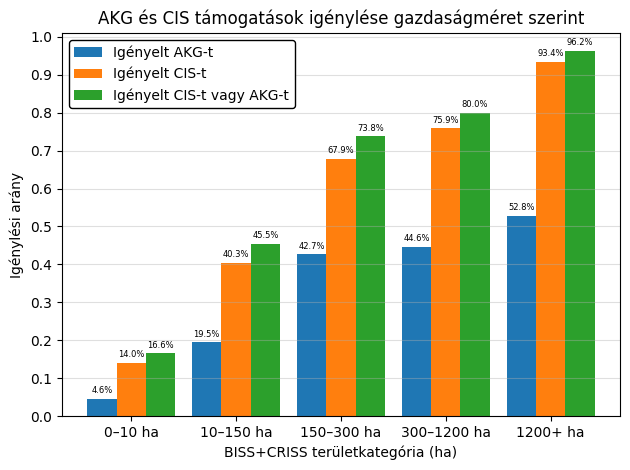

In [11]:
df = data.copy()

df["has_cis"] = np.where(
    df[
        [
            "subs_tk_cukorrepa",
            "subs_tk_szemes_feherjenoveny",
            "subs_tk_szalas_feherjenoveny",
            "subs_tk_extenziv_gyumolcs",
            "subs_tk_intenziv_gyumolcs",
            "subs_tk_ipari_olajnoveny",
            "subs_tk_ipari_zoldsegnoveny",
            "subs_tk_zoldsegnoveny",
            "subs_tk_rizs",
            "subs_tk_hizottbika",
            "subs_tk_anyatehen",
            "subs_tk_tejhasznu_tehen",
            "subs_tk_anyajuh",
        ]
    ]
    .fillna(0)
    .sum(axis=1)
    > 0,
    1,
    0,
)

df["has_akg"] = np.where(df["subs_vp_akg_2021"].fillna(0) > 0, 1, 0)

df["has_one"] = np.where((df["has_akg"] == 1) | (df["has_cis"] == 1), 1, 0)
df["has_akg"] = np.where(df["has_akg"] == 1, 1, 0)
df["has_cis"] = np.where(df["has_cis"] == 1, 1, 0)

df = df[df["area_biss_criss"] > 0].copy()

bins = [0, 10, 150, 300, 1200, float("inf")]
labels = generate_labels_from_bins(bins)
df["area_bin"] = pd.cut(df["area_biss_criss"], bins=bins, labels=labels, right=False)

g = (
    df.groupby("area_bin", observed=True)
    .agg(
        akg_share=("has_akg", "mean"),
        cis_share=("has_cis", "mean"),
        one_share=("has_one", "mean"),
        count=("area_biss_criss", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots()

x = np.arange(len(g))
width = 0.28

bars_akg = ax.bar(x - width, g["akg_share"], width, label="Igényelt AKG-t")
bars_cis = ax.bar(x, g["cis_share"], width, label="Igényelt CIS-t")
bars_one = ax.bar(x + width, g["one_share"], width, label="Igényelt CIS-t vagy AKG-t")

ax.set_xticks(x)
ax.set_xticklabels(g["area_bin"])
ax.set_xlabel("BISS+CRISS területkategória (ha)")
ax.set_ylabel("Igénylési arány")
ax.set_title("AKG és CIS támogatások igénylése gazdaságméret szerint")

ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.grid(axis="y", alpha=0.4)

ax.legend(frameon=True, fancybox=True, framealpha=1, edgecolor="black")


def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.010,  # offset above bar
            f"{h * 100:.1f}%",  # format as percent
            ha="center",
            va="bottom",
            fontsize=6,
        )


add_labels(bars_akg)
add_labels(bars_cis)
add_labels(bars_one)

plt.tight_layout()
plt.savefig("akg_cis_001.png", dpi=300, bbox_inches="tight")
plt.show()

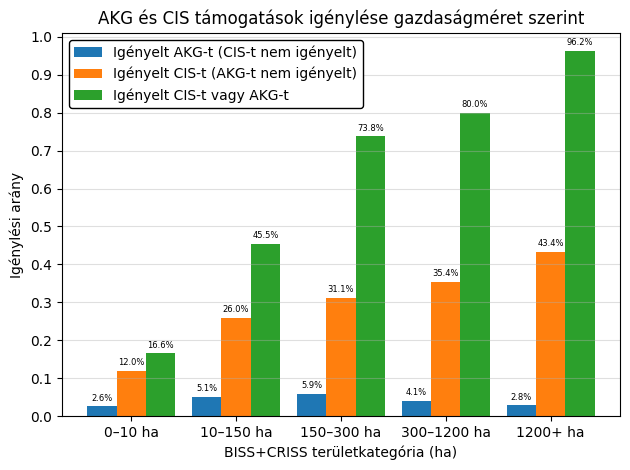

In [12]:
df = data.copy()

df["has_cis"] = np.where(
    df[
        [
            "subs_tk_cukorrepa",
            "subs_tk_szemes_feherjenoveny",
            "subs_tk_szalas_feherjenoveny",
            "subs_tk_extenziv_gyumolcs",
            "subs_tk_intenziv_gyumolcs",
            "subs_tk_ipari_olajnoveny",
            "subs_tk_ipari_zoldsegnoveny",
            "subs_tk_zoldsegnoveny",
            "subs_tk_rizs",
            "subs_tk_hizottbika",
            "subs_tk_anyatehen",
            "subs_tk_tejhasznu_tehen",
            "subs_tk_anyajuh",
        ]
    ]
    .fillna(0)
    .sum(axis=1)
    > 0,
    1,
    0,
)


df["has_akg"] = np.where(df["subs_vp_akg_2021"].fillna(0) > 0, 1, 0)


df["has_one"] = np.where((df["has_akg"] == 1) | (df["has_cis"] == 1), 1, 0)
df["only_akg"] = np.where((df["has_akg"] == 1) & (df["has_cis"] == 0), 1, 0)
df["only_cis"] = np.where((df["has_akg"] == 0) & (df["has_cis"] == 1), 1, 0)


df = df[df["area_biss_criss"] > 0].copy()

bins = [0, 10, 150, 300, 1200, float("inf")]
labels = generate_labels_from_bins(bins)
df["area_bin"] = pd.cut(df["area_biss_criss"], bins=bins, labels=labels, right=False)

g = (
    df.groupby("area_bin", observed=True)
    .agg(
        akg_share=("only_akg", "mean"),
        cis_share=("only_cis", "mean"),
        one_share=("has_one", "mean"),
        count=("area_biss_criss", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots()

x = np.arange(len(g))
width = 0.28

bars_akg = ax.bar(
    x - width, g["akg_share"], width, label="Igényelt AKG-t (CIS-t nem igényelt)"
)
bars_cis = ax.bar(x, g["cis_share"], width, label="Igényelt CIS-t (AKG-t nem igényelt)")
bars_one = ax.bar(x + width, g["one_share"], width, label="Igényelt CIS-t vagy AKG-t")


ax.set_xticks(x)
ax.set_xticklabels(g["area_bin"])
ax.set_xlabel("BISS+CRISS területkategória (ha)")
ax.set_ylabel("Igénylési arány")
ax.set_title("AKG és CIS támogatások igénylése gazdaságméret szerint")


ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.grid(axis="y", alpha=0.4)

ax.legend()
ax.legend(frameon=True, fancybox=True, framealpha=1, edgecolor="black")


def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.010,  # offset above bar
            f"{h * 100:.1f}%",  # format as percent
            ha="center",
            va="bottom",
            fontsize=6,
        )


add_labels(bars_akg)
add_labels(bars_cis)
add_labels(bars_one)

plt.tight_layout()
plt.savefig("akg_cis_002.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# tbl_res = plot_support_summary_by_area_class(
#     data,
#     coupled_payments,
#     DABIS_PER_HA,
#     REDIST_PER_HA,
#     bins,
#     labels,
#     DABIS_BUDGET,
#     CIS_NEW / CIS_CUR,
#     200,
# )

# tbl_res

In [ ]:
bins = [0, 10, 150, 300, 1200, float("inf")]
labels = generate_labels_from_bins(bins)

print(f"CIS arány: {c_round(CIS_NEW / CIS_CUR, 2)}.")

plot_support_summary_by_area_class(
    data,
    coupled_payments,
    DABIS_PER_HA,
    REDIST_PER_HA,
    bins,
    labels,
    DABIS_BUDGET,
    CIS_NEW / CIS_CUR,
    200,
)

In [ ]:
def create_data_for_hist(
    data: pd.DataFrame,
    dabis_per_ha: float,
    redist_per_ha: tuple[float, float],
    cis_ratio: float = 1,
    flat_rate: float = 0,
) -> None:
    data_with_subs = compute_capped_subsidies(data, dabis_per_ha, 90, redist_per_ha)

    cis_columns = [
        "subs_tk_cukorrepa",
        "subs_tk_szemes_feherjenoveny",
        "subs_tk_szalas_feherjenoveny",
        "subs_tk_extenziv_gyumolcs",
        "subs_tk_intenziv_gyumolcs",
        "subs_tk_ipari_olajnoveny",
        "subs_tk_ipari_zoldsegnoveny",
        "subs_tk_zoldsegnoveny",
        "subs_tk_rizs",
        "subs_tk_hizottbika",
        "subs_tk_anyatehen",
        "subs_tk_tejhasznu_tehen",
        "subs_tk_anyajuh",
    ]

    data_with_subs["subs_cur"] = (
        data_with_subs["subs_biss"]
        + data_with_subs["subs_redist"]
        + data_with_subs["subs_yfs"]
        + data_with_subs[cis_columns].fillna(0).sum(axis=1)
        + data_with_subs["subs_aop"].fillna(0)
        + data_with_subs["subs_vp_akg_2021"].fillna(0)
    )

    data_with_subs["subs_capped"] += (
        cis_ratio * data_with_subs[cis_columns].fillna(0).sum(axis=1)
        + flat_rate * data_with_subs["area_aop"]
    )
    return data_with_subs


tbl = create_data_for_hist(data, DABIS_PER_HA, REDIST_PER_HA, CIS_NEW / CIS_CUR, 200)

tbl

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    [tbl["subs_total"], tbl["subs_capped"]],
    bins=40,
    alpha=0.6,
    label=["MFF - jelenlegi", "MFF - új"],
)
plt.yscale("log")
plt.xlabel("Value")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of subs_total vs subs_cur")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
plt.boxplot(
    [tbl["subs_total"], tbl["subs_capped"]],
    labels=["Jelenlegi", "Új"],
    showfliers=False,
)
plt.yscale("log")
plt.ylabel("Támogatási összeg (log)")
plt.title("Támogatási eloszlások összevetése – Boxplot (log-skála)")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

for col, label in [("subs_total", "MFF - jelenlegi"), ("subs_capped", "MFF - új")]:
    vals = np.log10(tbl[col][tbl[col] > 0])

    hist, bin_edges = np.histogram(vals, bins=80, density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    plt.hist(vals, bins=80, alpha=0.2, density=True)

    plt.plot(bin_centers, hist, label=label)

plt.xlabel("log10(támogatási összeg)")
plt.ylabel("Sűrűség")
plt.title("Eloszlás összehasonlítása – log-skálán")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
x = tbl["area_biss_criss"]
y1 = tbl["subs_total"]
y2 = tbl["subs_capped"]

plt.figure(figsize=(8, 5))

plt.scatter(x, y1, s=5, alpha=0.3, label="subs_total")
plt.scatter(x, y2, s=5, alpha=0.3, label="subs_capped")

plt.xlabel("biss_criss_areat")
plt.ylabel("Támogatás összege")
plt.xscale("log")
plt.yscale("log")
plt.title("subs_total és subs_capped a biss_criss_areat függvényében")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(data["subs_total"], bins=40)
plt.yscale("log")
plt.xlabel("subs_total")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of subs_total")
plt.show()

In [ ]:
x = tbl["area_biss_criss"].to_numpy()
y1 = tbl["subs_total"].to_numpy()
y2 = tbl["subs_capped"].to_numpy()

bins = np.linspace(x.min(), x.max(), 50)
idx = np.digitize(x, bins)

bin_centers = []
mean_y1 = []
mean_y2 = []

for i in range(1, len(bins)):
    mask = idx == i
    if mask.sum() == 0:  # ha nincs adat → kihagyjuk
        continue
    bin_centers.append(0.5 * (bins[i] + bins[i - 1]))
    mean_y1.append(y1[mask].mean())
    mean_y2.append(y2[mask].mean())

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, mean_y1, label="subs_total – átlag", linewidth=2)
plt.plot(bin_centers, mean_y2, label="subs_capped – átlag", linewidth=2)

plt.xlabel("biss_criss_areat")
plt.ylabel("Átlagos támogatás (EUR)")
plt.xscale("log")
plt.yscale("log")
plt.title("Átlagos subs_total vs subs_capped a terület függvényében")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
tbl_filtered = tbl[tbl["area_biss_criss"] <= 1_000]
area = tbl_filtered["area_biss_criss"].to_numpy()
tot = tbl_filtered["subs_total"].to_numpy()
cap = tbl_filtered["subs_capped"].to_numpy()

loss = cap - tot

mask_pos = area >= 1
area = area[mask_pos]
loss = loss[mask_pos]
tot = tot[mask_pos]


bins = np.logspace(np.log10(area.min()), np.log10(area.max()), 40)
idx = np.digitize(area, bins)

bin_centers = []
mean_loss = []

for i in range(1, len(bins)):
    m = idx == i
    if m.sum() == 0:
        continue
    bin_centers.append(0.5 * (bins[i] + bins[i - 1]))
    mean_loss.append(loss[m].mean())

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, mean_loss, linewidth=2)

# plt.xscale("log")
plt.xlabel("biss_criss_areat")
plt.ylabel("Átlagos növekedés (EUR)")
plt.title("Capping miatti átlagos támogatásnövekedés a terület függvényében")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

In [ ]:
tbl_filtered = tbl[tbl["area_biss_criss"] <= 1_000]
area = tbl_filtered["area_biss_criss"].to_numpy()
tot = tbl_filtered["subs_total"].to_numpy()
cap = tbl_filtered["subs_capped"].to_numpy()

rel_change = (cap - tot) / tot * 100

mask_pos = area > 1
area = area[mask_pos]
rel_change = rel_change[mask_pos]

bins = np.logspace(np.log10(area.min()), np.log10(area.max()), 40)
idx = np.digitize(area, bins)

bin_centers = []
mean_rel = []

for i in range(1, len(bins)):
    m = idx == i
    if m.sum() == 0:
        continue
    bin_centers.append(0.5 * (bins[i] + bins[i - 1]))
    mean_rel.append(rel_change[m].mean())

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, mean_rel, linewidth=2)

# plt.xscale("log")
plt.xlabel("biss_criss_areat (ha)")
plt.ylabel("Átlagos változás (%)")
plt.title("Capping miatti átlagos relatív támogatásváltozás a terület függvényében")
plt.axhline(0, linestyle="--", color="gray")
plt.tight_layout()
plt.show()

In [ ]:
ENVCLIM_env = c_round((data["area_aop"].sum() * 180) / 1e6, 2)

print(f"Az ENVCLIM boríték mérete: {ENVCLIM_env:.2f} M EUR")

In [ ]:
100 / (100 - 75.36541246472103)

In [ ]:
187 * 4

In [ ]:
data["area_aop"].sum()

In [ ]:
NRF / (data["area_aop"].sum() * 180)

In [ ]:
(data["area_aop"].sum() * 180) / 1e6

In [ ]:
((data["area_aop"].sum() * 180) - NRF) / 1e6

In [ ]:
100 * (1 - NRF / (data["area_aop"].sum() * 180))

In [ ]:
df = data[data["area_biss_criss"] >= 1].copy()
name_dict = {0: "Nem kizárólag BISS/CRISS/YFS", 1: "Kizárólag BISS/CRISS/YFS"}

farm_share = (
    df["only_biss_criss_yfs"].value_counts(normalize=True).rename(name_dict) * 100
)

area_share = (
    df.groupby("only_biss_criss_yfs")["area_biss_criss"].sum().rename(name_dict)
)
area_share = area_share / area_share.sum() * 100

combined = pd.DataFrame(
    {"Üzemszám aránya (%)": farm_share, "Terület aránya (%)": area_share}
)

sns.set_style("whitegrid")
ax = combined.plot(kind="bar", figsize=(7, 5))

for i, col in enumerate(combined.columns):
    for j, val in enumerate(combined[col]):
        ax.text(j + i * 0.25 - 0.12, val + 1, f"{val:.1f}%", ha="center", fontsize=10)

plt.ylabel("Arány (%)")
plt.xlabel("")
plt.ylim(0, combined.to_numpy().max() * 1.25)
plt.title("Üzemszám és terület megoszlása")
plt.xticks(rotation=0)

plt.show()

In [ ]:
df = data[data["area_biss_criss"] >= 150].copy()
share = (
    df["only_biss_criss_yfs"]
    .value_counts(normalize=True)
    .rename({0: "Not only BISS/CRISS/YFS", 1: "Only BISS/CRISS/YFS"})
    * 100
)

sns.set_style("whitegrid")
ax = sns.barplot(x=share.index, y=share.values)

for i, v in enumerate(share.values):
    ax.text(i, v + 1, f"{v:.2f}%", ha="center", fontsize=11, fontweight="bold")

plt.ylabel("Share of farms (%)")
plt.xlabel("")
plt.ylim(0, max(share.values) * 1.2)
plt.show()

In [ ]:
sns.boxplot(data=data, x="only_biss_criss_yfs", y="area_biss_criss")
plt.xlabel("Only BISS+CRISS+YFS? (1=yes, 0=no)")
plt.ylabel("Area (ha)")
plt.show()

In [ ]:
calc_degressive_and_capping_steps(data, DABIS_PER_HA, REDIST_PER_HA, 90, "yf")

In [ ]:
calc_degressive_and_capping_steps(data, DABIS_PER_HA, REDIST_PER_HA, 0, "not-yf")

In [ ]:
policy_non_yfs = PolicyParams(
    base_payment_per_ha=DABIS_PER_HA, yfs_per_ha=0, redist_params=REDIST_PER_HA
)

policy_yfs = PolicyParams(
    base_payment_per_ha=DABIS_PER_HA, yfs_per_ha=90, redist_params=REDIST_PER_HA
)

In [ ]:
plot_per_ha(
    policy_non_yfs,
    label1="DABIS",
    label2="BISS+CRISS",
    title="Hektáronkénti támogatás alakulása (nem fiatal gazdálkodó)",
    output_path="output/abra_01_per_ha_non_yf.png",
)

In [ ]:
plot_support_summary_by_area_class(
    data, coupled_payments, 190, REDIST_PER_HA, bins, labels, 943_000_000
)

In [ ]:
plot_support_summary_by_area_class(
    data, coupled_payments, DABIS_PER_HA, REDIST_PER_HA, bins, labels, DABIS_BUDGET
)

In [ ]:
res = sorted(data.loc[data["area_aop"] == 0, "area_biss_criss"])

In [ ]:
# df = data.copy().drop("regszam", axis=1).sort_values(by="area_biss_criss")
# df.to_csv("data_2024_extended.csv", index=False)

In [ ]:
np.where(data["area_aop"] > 0, 1, 0)

In [ ]:
x = data["area_biss_criss"].values
y = data["ratio"].values

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()
print(model.summary())


y_pred = model.predict(X)

intercept = model.params[0]
slope = model.params[1]
r2 = model.rsquared

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label="Data points")
plt.plot(x, y_pred, color="red", label="OLS regression")

eq_text = f"y = {slope:.4f}·x + {intercept:.2f}\nR² = {r2:.4f}"

plt.text(
    0.05,
    0.95,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)

plt.xlabel("Area (BISS+CRISS)")
plt.ylabel("Ratio")
plt.title("Subsidies ratio vs. Eligible Area (OLS Regression)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
x = data["area_biss_criss"].values
y = data["subs_total"].values

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()
print(model.summary())


y_pred = model.predict(X)

intercept = model.params[0]
slope = model.params[1]
r2 = model.rsquared

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label="Data points")
plt.plot(x, y_pred, color="red", label="OLS regression")

eq_text = f"y = {slope:.4f}·x + {intercept:.2f}\nR² = {r2:.4f}"

plt.text(
    0.05,
    0.95,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7),
)

plt.xlabel("Area (BISS+CRISS)")
plt.ylabel("Total subsidies")
plt.title("Subsidies vs. Eligible Area (OLS Regression)")
plt.grid(True)
plt.legend()
plt.show()